## N-BEATS (Neural Basis Expansion Analysis for Interpretable Time Series Forecasting)

⚠️ NOTE: This is a HARD-CODED version of N-BEATS, different from the implementation in the paper due to the revisions in the corresponding python library

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, horizon_size, hidden_size, n_layers):
        """
        Base N-BEATS block

        Args:
            input_size: length of backcast window
            theta_size: size of theta (expansion coefficients)
            horizon_size: length of forecast horizon
            hidden_size: hidden layer size
            n_layers: number of hidden layers
        """
        super().__init__()
        self.input_size = input_size
        self.theta_size = theta_size
        self.horizon_size = horizon_size

        # Build fully connected layers
        layers = []
        for i in range(n_layers):
            in_size = input_size if i == 0 else hidden_size
            layers.append(nn.Linear(in_size, hidden_size))
            layers.append(nn.ReLU())
        self.fc_layers = nn.Sequential(*layers)

        # Theta layer: outputs expansion coefficients
        self.theta_layer = nn.Linear(hidden_size, theta_size)

    def forward(self, x):
        # x shape: (batch_size, input_size)
        hidden = self.fc_layers(x)
        theta = self.theta_layer(hidden)  # (batch_size, theta_size)
        return theta


class GenericBlock(NBeatsBlock):
    """Generic block with learnable backcast and forecast basis"""

    def __init__(self, input_size, horizon_size, hidden_size, n_layers):
        theta_size = input_size + horizon_size  # Generic theta combines both
        super().__init__(input_size, theta_size, horizon_size, hidden_size, n_layers)

        # Learnable basis matrices
        self.backcast_basis = nn.Linear(theta_size, input_size, bias=False)
        self.forecast_basis = nn.Linear(theta_size, horizon_size, bias=False)

    def forward(self, x):
        theta = super().forward(x)  # (batch_size, theta_size)
        backcast = self.backcast_basis(theta)  # (batch_size, input_size)
        forecast = self.forecast_basis(theta)  # (batch_size, horizon_size)
        return backcast, forecast


class TrendBlock(NBeatsBlock):
    """Interpretable block for trend using polynomial basis"""

    def __init__(self, input_size, horizon_size, hidden_size, n_layers, degree=2):
        theta_size = degree + 1  # Polynomial coefficients: a0 + a1*t + a2*t^2 + ...
        super().__init__(input_size, theta_size, horizon_size, hidden_size, n_layers)
        self.degree = degree

        # Precompute polynomial basis matrices (fixed, not learnable)
        t_backcast = np.arange(0, input_size, dtype=np.float32) / input_size
        t_forecast = np.arange(input_size, input_size + horizon_size, dtype=np.float32) / input_size

        # Build polynomial basis: [1, t, t^2, ..., t^degree]
        self.register_buffer(
            'backcast_basis',
            torch.tensor(np.vstack([t_backcast ** i for i in range(degree + 1)]).T, dtype=torch.float32)
        )
        self.register_buffer(
            'forecast_basis',
            torch.tensor(np.vstack([t_forecast ** i for i in range(degree + 1)]).T, dtype=torch.float32)
        )

    def forward(self, x):
        theta = super().forward(x)  # (batch_size, degree+1)
        backcast = torch.mm(theta, self.backcast_basis.T)  # (batch_size, input_size)
        forecast = torch.mm(theta, self.forecast_basis.T)  # (batch_size, horizon_size)
        return backcast, forecast


class SeasonalityBlock(NBeatsBlock):
    """Interpretable block for seasonality using harmonic (Fourier) basis"""

    def __init__(self, input_size, horizon_size, hidden_size, n_layers, n_harmonics=2):
        theta_size = 2 * n_harmonics  # sin and cos coefficients for each harmonic
        super().__init__(input_size, theta_size, horizon_size, hidden_size, n_layers)
        self.n_harmonics = n_harmonics

        # Precompute harmonic basis matrices (fixed, not learnable)
        t_backcast = np.arange(0, input_size, dtype=np.float32)
        t_forecast = np.arange(input_size, input_size + horizon_size, dtype=np.float32)

        backcast_basis = []
        forecast_basis = []

        for i in range(1, n_harmonics + 1):
            # sin and cos for each harmonic
            backcast_basis.append(np.sin(2 * np.pi * i * t_backcast / horizon_size))
            backcast_basis.append(np.cos(2 * np.pi * i * t_backcast / horizon_size))
            forecast_basis.append(np.sin(2 * np.pi * i * t_forecast / horizon_size))
            forecast_basis.append(np.cos(2 * np.pi * i * t_forecast / horizon_size))

        self.register_buffer(
            'backcast_basis',
            torch.tensor(np.vstack(backcast_basis).T, dtype=torch.float32)
        )
        self.register_buffer(
            'forecast_basis',
            torch.tensor(np.vstack(forecast_basis).T, dtype=torch.float32)
        )

    def forward(self, x):
        theta = super().forward(x)  # (batch_size, 2*n_harmonics)
        backcast = torch.mm(theta, self.backcast_basis.T)  # (batch_size, input_size)
        forecast = torch.mm(theta, self.forecast_basis.T)  # (batch_size, horizon_size)
        return backcast, forecast


class NBeatsStack(nn.Module):
    """A stack of blocks with shared characteristics"""

    def __init__(self, block_class, input_size, horizon_size, hidden_size, n_layers, n_blocks, **kwargs):
        super().__init__()
        self.blocks = nn.ModuleList([
            block_class(input_size, horizon_size, hidden_size, n_layers, **kwargs)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual = x
        stack_output = torch.zeros(x.size(0), self.blocks[0].horizon_size, device=x.device)

        for block in self.blocks:
            backcast, forecast = block(residual)
            residual = residual - backcast
            stack_output = stack_output + forecast

        return residual, stack_output


class NBeats(nn.Module):
    """
    Original N-BEATS model as described in the paper

    Supports both Generic and Interpretable configurations
    """

    def __init__(
        self,
        input_size,
        horizon_size,
        stack_types=['generic'],  # or ['trend', 'seasonality'] for interpretable
        n_blocks_per_stack=3,
        hidden_size=256,
        n_layers=4,
        trend_degree=2,
        n_harmonics=2,
        share_weights=False  # Not implemented in this version
    ):
        super().__init__()
        self.input_size = input_size
        self.horizon_size = horizon_size
        self.stack_types = stack_types
        self.share_weights = share_weights

        # Map stack type to block class and kwargs
        stack_map = {
            'generic': (GenericBlock, {}),
            'trend': (TrendBlock, {'degree': trend_degree}),
            'seasonality': (SeasonalityBlock, {'n_harmonics': n_harmonics})
        }

        # Build stacks
        self.stacks = nn.ModuleList()
        for stack_type in stack_types:
            block_class, kwargs = stack_map[stack_type]
            stack = NBeatsStack(
                block_class=block_class,
                input_size=input_size,
                horizon_size=horizon_size,
                hidden_size=hidden_size,
                n_layers=n_layers,
                n_blocks=n_blocks_per_stack,
                **kwargs
            )
            self.stacks.append(stack)

    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, input_size)
        Returns:
            forecast: Tensor of shape (batch_size, horizon_size)
        """
        residual = x
        forecast = torch.zeros(x.size(0), self.horizon_size, device=x.device)

        for stack in self.stacks:
            residual, stack_output = stack(residual)
            forecast = forecast + stack_output

        return forecast

In [4]:
import yfinance as yf
import pandas as pd

start_date = "2015-05-01"
end_date = "2024-05-08"

stock_data = yf.Ticker('HSBC')
stock_data = stock_data.history(start=start_date, end=end_date)
stock_data.index = pd.to_datetime(stock_data.index)
stock_data['date'] = stock_data.index
stock_data.reset_index(drop=True, inplace=True)
stock_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,date
0,25.722848,25.785675,25.576248,25.775204,2339300,0.0,0.0,2015-05-01 00:00:00-04:00
1,25.691432,25.759496,25.628604,25.707138,2028400,0.0,0.0,2015-05-04 00:00:00-04:00
2,25.220223,25.246403,24.879906,24.906084,3675800,0.0,0.0,2015-05-05 00:00:00-04:00
3,25.220223,25.319702,25.141690,25.262110,2533800,0.0,0.0,2015-05-06 00:00:00-04:00
4,25.178337,25.256873,24.942731,25.225458,1678800,0.0,0.0,2015-05-07 00:00:00-04:00
...,...,...,...,...,...,...,...,...
2265,37.914114,38.043925,37.654484,37.775646,2274400,0.0,0.0,2024-05-01 00:00:00-04:00
2266,38.641059,38.684330,38.260272,38.519897,2160700,0.0,0.0,2024-05-02 00:00:00-04:00
2267,38.658370,38.779532,38.467979,38.467979,1466100,0.0,0.0,2024-05-03 00:00:00-04:00
2268,38.718949,38.788181,38.502593,38.753563,1276700,0.0,0.0,2024-05-06 00:00:00-04:00


In [5]:
def create_sequences(data, backcast_size, forecast_size):
    x, y = [], []
    for i in range(len(data) - backcast_size - forecast_size):
        x.append(data[i:i+backcast_size])
        y.append(data[i+backcast_size:i+backcast_size+forecast_size])
    return np.array(x), np.array(y)

# Extract close price
close_prices = stock_data["Close"].values

min_val = close_prices.min()
max_val = close_prices.max()

# Apply Min-Max scaling: scale to [0, 1]
close_prices_scaled = (close_prices - min_val) / (max_val - min_val)


backcast_size = 5  # past five days
forecast_size = 1   # next day close

X, Y = create_sequences(close_prices_scaled, backcast_size, forecast_size)

In [6]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Split X and Y (e.g., 70% train, 30% test)
split_idx = int(len(X) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, Y_test_tensor), batch_size=32, shuffle=False)

In [ ]:
# For Generic configuration (most common for stock prediction)
model = NBeats(
    input_size=backcast_size,        # renamed from backcast_size
    horizon_size=forecast_size,       # renamed from forecast_size
    stack_types=['generic'],          # use generic blocks
    n_blocks_per_stack=4,             # number of blocks per stack (default: 3)
    hidden_size=256,                  # hidden layer size (default: 256)
    n_layers=4,                       # number of hidden layers per block (default: 4)
    trend_degree=2,                   # only used for trend blocks
    n_harmonics=2                     # only used for seasonality blocks
)

# For Interpretable configuration (trend + seasonality)
model = NBeats(
    input_size=backcast_size,
    horizon_size=forecast_size,
    stack_types=['trend', 'seasonality'],  # two stacks for interpretability
    n_blocks_per_stack=3,
    hidden_size=256,
    n_layers=4,
    trend_degree=2,
    n_harmonics=2
)

# Or a combination (generic + trend + seasonality)
model = NBeats(
    input_size=backcast_size,
    horizon_size=forecast_size,
    stack_types=['generic', 'trend', 'seasonality'],
    n_blocks_per_stack=3,
    hidden_size=256,
    n_layers=4
)

In [8]:

backcast_size = 5
forecast_size = 1

# Generic N-BEATS (simpler, often works well)
model = NBeats(
    input_size=backcast_size,
    horizon_size=forecast_size,
    stack_types=['generic'],
    n_blocks_per_stack=4,      # 4 blocks as in your original code
    hidden_size=128,            # 128 as in your original code
    n_layers=1                  # 1 layer as per your Toyota/Petrobras comment
)

# Optimizer and loss (these stay the same)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

In [9]:
# 5. Training loop
model.train()
for epoch in range(100):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        forecast = model(batch_x)  # Shape: (batch_size, forecast_size)
        loss = loss_fn(forecast, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(train_loader):.6f}")


Epoch 0, Loss: 0.014024
Epoch 10, Loss: 0.005765
Epoch 20, Loss: 0.000559
Epoch 30, Loss: 0.001551
Epoch 40, Loss: 0.000754
Epoch 50, Loss: 0.000436
Epoch 60, Loss: 0.000222
Epoch 70, Loss: 0.000223
Epoch 80, Loss: 0.000230
Epoch 90, Loss: 0.000285


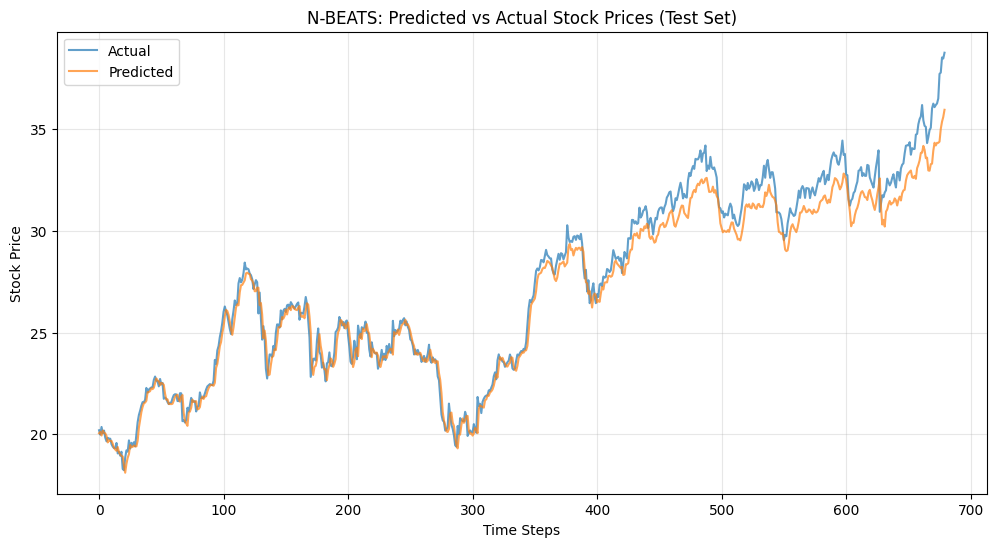

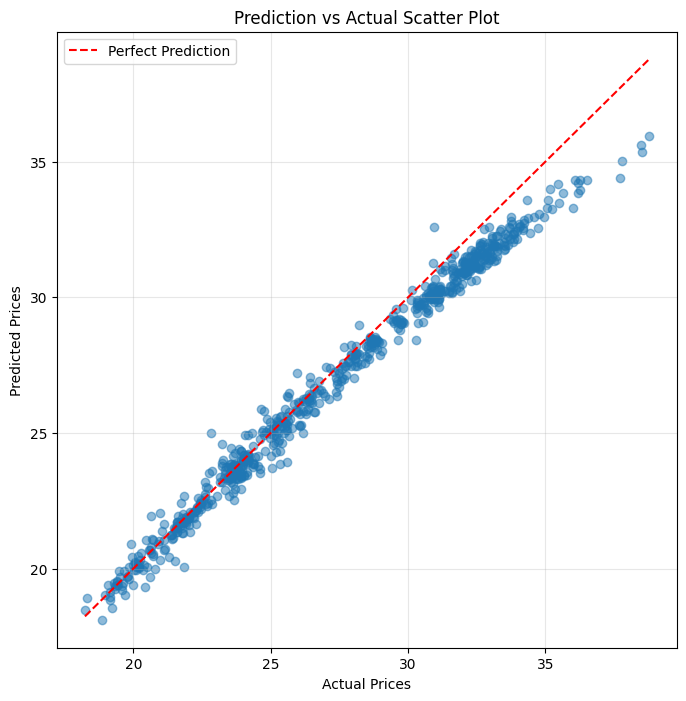


📊 Test Set Metrics:
MAE: 0.6598
MSE: 0.7443
RMSE: 0.8627
R² Score: 0.9658


In [11]:
import matplotlib.pyplot as plt

# 6. Evaluation and Visualization
model.eval()
all_predictions = []
all_actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_predictions = model(batch_x)
        all_predictions.append(batch_predictions.numpy())
        all_actuals.append(batch_y.numpy())

# Concatenate and inverse transform
predictions = np.concatenate(all_predictions, axis=0)
actuals = np.concatenate(all_actuals, axis=0)

predictions_original = predictions * (max_val - min_val) + min_val
actuals_original = actuals * (max_val - min_val) + min_val

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(actuals_original, label='Actual', alpha=0.7)
plt.plot(predictions_original, label='Predicted', alpha=0.7)
plt.title('N-BEATS: Predicted vs Actual Stock Prices (Test Set)')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals_original, predictions_original, alpha=0.5)
plt.plot([actuals_original.min(), actuals_original.max()],
         [actuals_original.min(), actuals_original.max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Prediction vs Actual Scatter Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(actuals_original, predictions_original)
mse = mean_squared_error(actuals_original, predictions_original)
rmse = np.sqrt(mse)
r2 = r2_score(actuals_original, predictions_original)

print(f"\n📊 Test Set Metrics:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
